# Exploratory Data Analysis (EDA) for Givemore

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Data

In [2]:
ratings = pd.read_csv("/home/bukunmi/code/givemore/data/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
movies = pd.read_csv("/home/bukunmi/code/givemore/data/movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
tags = pd.read_csv("/home/bukunmi/code/givemore/data/tags.csv")
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [5]:
links = pd.read_csv("/home/bukunmi/code/givemore/data/links.csv")
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


### **1.** What's the exact density of the user-movie matrix, and what does it imply for the minimum number of co-ratings before a similarity is meaningful?

  $$\text{density} = \frac{\text{ratings}}{\text{users} \times \text{movies}}$$

In [6]:
num_ratings = ratings["rating"].count()
print(f"Number of ratings: {num_ratings}")
num_users = ratings["userId"].nunique()
print(f"Number of users: {num_users}")
num_movies = movies["movieId"].nunique()
print(f"Number of movies: {num_movies}")

Number of ratings: 100836
Number of users: 610
Number of movies: 9742


In [7]:
density = num_ratings / (num_users * num_movies)
print(f"Density: {(density*100):.2f}%")

Density: 1.70%


At **_1.70%_** density the matrix is **_98.3%_** empty. The average user has rated 165 of 9,742 movies, and typical movie pairs share 0 raters. Behavioural (collaborative) similarity is therefore only reliable for the popular head; the long tail needs a content-based fallback and a minimum co-rating threshold to avoid spurious similarities.

In [8]:
movie_ratings_counts = ratings.groupby("movieId")["userId"].count()
movie_ratings_counts.describe()

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: userId, dtype: float64

In [9]:
U = num_users
med = movie_ratings_counts.median()   # typical movie
mx = movie_ratings_counts.max()       # blockbuster

print(f"predicted overlap, median x median ({med:.0f}x{med:.0f}): {med*med/U:.3f} -> nobody")
print(f"predicted overlap, max x max ({mx:.0f}x{mx:.0f}): {mx*mx/U:.1f} -> lots")

predicted overlap, median x median (3x3): 0.015 -> nobody
predicted overlap, max x max (329x329): 177.4 -> lots


In [10]:
thresholds = [2, 5, 10, 20, 50]
for t in thresholds:
    movies_with_enough_ratings = (movie_ratings_counts >= t).sum()
    print(f"Threshold: {t}, Movies with enough ratings: {movies_with_enough_ratings}")

Threshold: 2, Movies with enough ratings: 6278
Threshold: 5, Movies with enough ratings: 3650
Threshold: 10, Movies with enough ratings: 2269
Threshold: 20, Movies with enough ratings: 1297
Threshold: 50, Movies with enough ratings: 450


**_3446_** movies have less than **2** ratings

In [11]:
user_movie = ratings.assign(watched=1).pivot_table(
    index="userId",
    columns="movieId",
    values="watched",
    fill_value=0
)
user_movie

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
co_ratings = (user_movie.T @ user_movie).to_numpy().copy()
np.fill_diagonal(co_ratings, 0)

In [13]:
for t in thresholds:
    pair_count = (co_ratings >= t).sum().sum() // 2
    print(f"Movie pairs with at least {t} co-ratings: {pair_count:,}")

Movie pairs with at least 2 co-ratings: 4,738,640
Movie pairs with at least 5 co-ratings: 1,293,963
Movie pairs with at least 10 co-ratings: 434,435
Movie pairs with at least 20 co-ratings: 113,136
Movie pairs with at least 50 co-ratings: 9,912


The number of possible movie pairs is:
$$\frac{9724 \times 9723} {2}$$
which is 47,273,226 possible movie pairs

Although millions of movie pairs have at least 2 shared raters, this is still only a small fraction of all possible movie pairs. The drop-off is steep as the threshold increases: 5 co-ratings leaves about 1.29M pairs, 10 leaves about 434K, 20 leaves about 113K, and 50 leaves only about 9.9K.

The connected pairs exist, but they're concentrated among popular movies which is precisely why the long tail still needs a content fallback.

### Q1 Decision

**Density is 1.70% (98.3% empty).** The prediction held: typical movie pairs share **0** raters, while only blockbusters share many and the measured distribution confirms **90%** of all pairs share 0–1 raters, with connected pairs concentrated in the popular head.

**Decision:** require **>= 5 co-ratings** before trusting a collaborative similarity (keeps 1.29M pairs ≈ 2.7% of all possible). Below that threshold, fall back to **content similarity** so long-tail movies remain recommendable.

### **2.** How many movie *pairs* actually share enough common raters to compute a stable similarity?

Answered by Q1's co-rating analysis **1,293,963 pairs** clear the c=5 threshold

### **3.** How many movies are effectively un-recommendable because they have too few ratings to ever appear as a neighbour?

Based on the decision in Q1, we would require >= 5 co-ratings before trusting collaborative similarity. Movies with fewer that 5 ratings will be considered unrecommendable by cs.

In [14]:
min_common_users = 5

# including movies not rated at all
movie_ratings_counts_inc_na = (
    ratings.groupby("movieId")["userId"]
    .count()
    .reindex(movies["movieId"], fill_value=0)
)

unrecommendable_movies = movie_ratings_counts_inc_na[movie_ratings_counts_inc_na < min_common_users]
len(unrecommendable_movies)

6092

In [15]:
have_enough_ratings = int((movie_ratings_counts >= min_common_users).sum())
has_stable_neighbor = (co_ratings >= min_common_users).any(axis=1)
recommendable = int(has_stable_neighbor.sum())
never_rated = movies["movieId"].nunique() - co_ratings.shape[0]
unrecommendable_exact = (co_ratings.shape[0] - recommendable) + never_rated

print(f"recommendable (>=1 neighbour with >=5 co-raters): {recommendable}")
print(f"have >=5 ratings but NO stable neighbour: {have_enough_ratings - recommendable}")
print(f"exact un-recommendable: {unrecommendable_exact} ({unrecommendable_exact / movies['movieId'].nunique() * 100:.1f}% of catalogue)")

recommendable (>=1 neighbour with >=5 co-raters): 3634
have >=5 ratings but NO stable neighbour: 16
exact un-recommendable: 6108 (62.7% of catalogue)


**Lower bound (Layer 1):** Any movie with fewer than 5 ratings can never reach 5 shared raters with another movie (co-ratings <= min of the two movies' counts). That's **6092** movies guaranteed un-recommendable by collaborative filtering — 6074 with too few ratings, plus 18 never rated at all.

**Exact answer (Layer 2):** Having ≥ 5 ratings is *necessary* but not *sufficient* — a movie also needs one other movie its raters actually overlap with. Of the 3650 movies with ≥ 5 ratings, only **3634** have a stable neighbour; the other **16** have enough ratings but their raters are too scattered to overlap with any single film. So the exact figure is **6108 un-recommendable (62.7% of the catalogue)** — only **3634 movies (37.3%) are reachable by item-item collaborative filtering at all**.

The Layer-1 bound was nearly tight here (6092 vs 6108) — only 16 movies fall in the gap — so for this dataset "too few ratings" is almost the whole story.

**Implication:** these 6100 movies are not unrecommendable *in general* — they just need a non-collaborative path: content (genre/title) similarity or popularity fallback. With 63% of the catalogue CF-invisible, the content path is carrying the majority of the long tail, not just patching edge cases.

# ==============================================================================

### **4.** Is the rating distribution biased per-user?

In [16]:
user_rating_stats = ratings.groupby("userId")["rating"].agg(["count", "mean", "std", "min", "max"])
user_rating_stats.describe()

,count,mean,std,min,max
count,610.000000,610.000000,610.000000,610.000000,610.000000
mean,165.304918,3.657222,0.927116,1.314754,4.957377
std,269.480584,0.480635,0.266108,0.835449,0.191750
min,20.000000,1.275000,0.000000,0.500000,2.500000
25%,35.000000,3.360000,0.736026,0.500000,5.000000
50%,70.500000,3.694385,0.902378,1.000000,5.000000
75%,168.000000,3.997500,1.079056,2.000000,5.000000
max,2698.000000,5.000000,2.090642,5.000000,5.000000


In [17]:
user_rating_stats.sort_values("mean").head(10)

,count,mean,std,min,max
userId,,,,,
442,20,1.275000,0.697269,0.5,2.5
139,194,2.144330,0.894597,0.5,4.0
508,24,2.145833,1.057881,1.0,4.5
153,179,2.217877,1.431984,0.5,5.0
567,385,2.245455,1.221076,0.5,5.0
311,28,2.339286,1.262373,0.5,4.5
298,939,2.363685,1.082449,0.5,5.0
517,400,2.386250,1.347581,0.5,5.0
308,115,2.426087,1.498894,0.5,5.0


In [18]:
user_rating_stats.sort_values("mean", ascending=False).head(10)

,count,mean,std,min,max
userId,,,,,
53,20,5.000000,0.000000,5.0,5.0
251,23,4.869565,0.526942,2.5,5.0
515,26,4.846154,0.339683,4.0,5.0
25,26,4.807692,0.376216,4.0,5.0
30,34,4.735294,0.553711,3.0,5.0
523,75,4.693333,0.449424,3.0,5.0
348,55,4.672727,0.432672,3.5,5.0
171,82,4.634146,0.598603,3.0,5.0
452,202,4.556931,0.605100,2.0,5.0


<Axes: >

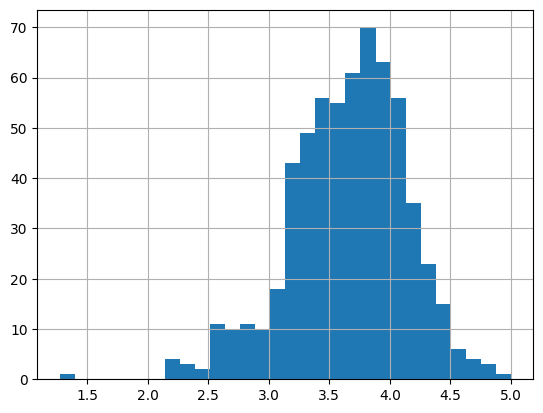

In [19]:
user_rating_stats["mean"].hist(bins=30)

<Axes: >

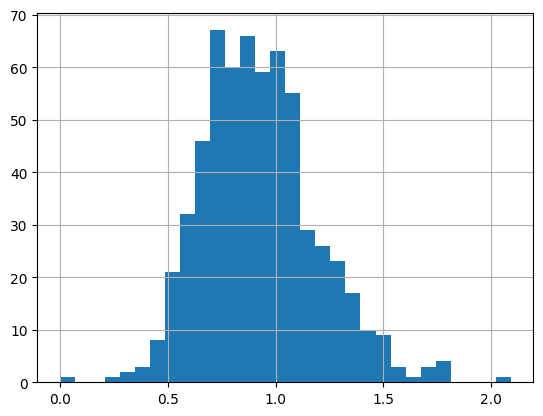

In [20]:
user_rating_stats["std"].hist(bins=30)

**Q4 Decision:** User means span 1.27–5.0 (std 0.48), and the bias persists among high-activity users (e.g. user 298: 939 ratings, mean 2.36) — so it's a real baseline effect, not small-sample noise. **_Therefore use adjusted cosine similarity (mean-center each user's ratings) for collaborative similarity, not raw cosine._**

### **5.** Do users use half-stars, or cluster on whole numbers?

<Axes: xlabel='rating'>

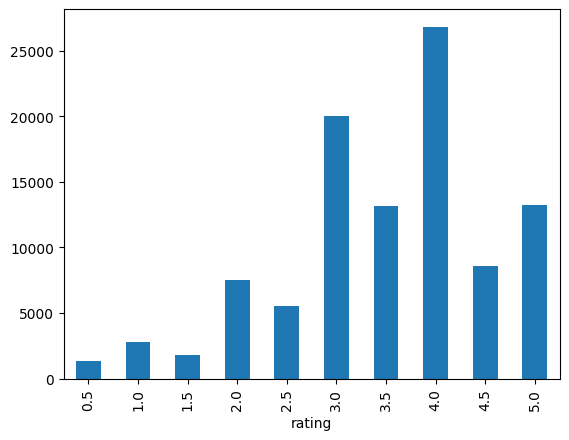

In [21]:
ratings_per_user = ratings.groupby("rating")["userId"].count()
ratings_per_user.plot(kind="bar")

In [22]:
whole = ratings.loc[ratings["rating"] % 1 == 0, "rating"].count()
half = ratings.loc[ratings["rating"] % 1 != 0, "rating"].count()
print(f"Whole ratings: {whole}, Half ratings: {half}")

Whole ratings: 70438, Half ratings: 30398


Users cluster on whole numbers (about 70%), but half-stars are genuinely used (about 30%)

### **6.** Does average rating correlate with rating count?

In [23]:
ratings_per_movie = ratings.groupby("movieId")["rating"].agg(["count", "mean"])
ratings_per_movie.sort_values("count", ascending=False).head(10)

,count,mean
movieId,,
356,329,4.164134
318,317,4.429022
296,307,4.197068
593,279,4.161290
2571,278,4.192446
260,251,4.231076
480,238,3.750000
110,237,4.031646
589,224,3.970982


In [24]:
pearson_corr = ratings_per_movie["count"].corr(
    ratings_per_movie["mean"],
    method="pearson"
)

spearman_corr = ratings_per_movie["count"].corr(
    ratings_per_movie["mean"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.127
Spearman correlation: 0.040


In [25]:
for min_count in [1, 5, 10, 20, 50]:
    subset = ratings_per_movie[ratings_per_movie["count"] >= min_count]

    pearson = subset["count"].corr(subset["mean"], method="pearson")
    spearman = subset["count"].corr(subset["mean"], method="spearman")
    print(f"Min count: {min_count}, Pearson: {pearson:.3f}, Spearman: {spearman:.3f}")

Min count: 1, Pearson: 0.127, Spearman: 0.040
Min count: 5, Pearson: 0.257, Spearman: 0.236
Min count: 10, Pearson: 0.278, Spearman: 0.251
Min count: 20, Pearson: 0.303, Spearman: 0.266
Min count: 50, Pearson: 0.343, Spearman: 0.311


<Axes: xlabel='count', ylabel='mean'>

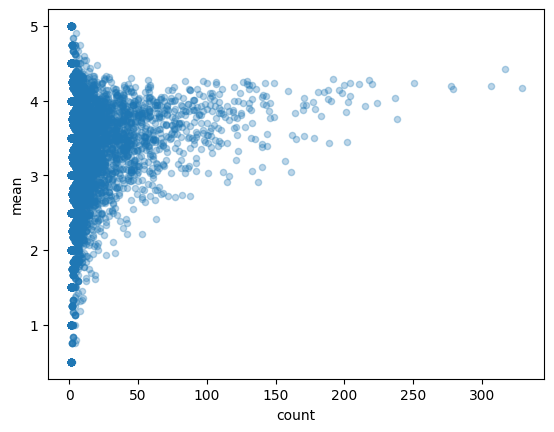

In [26]:
ratings_per_movie.plot(
    kind="scatter",
    x="count",
    y="mean",
    alpha=0.3,
)

**Q6 Decision:** Rating count and average are nearly uncorrelated overall (Spearman 0.040) — popularity _is not equal to_ quality, a 5.0 average is as likely on an obscure film as a hit. Confirms raw-average ranking would surface low-count flukes, so the weighted (Bayesian) popularity score with smoothing constant m is necessary.

### **7.** What's the right value for `m` (smoothing constant) in the weighted score?

Weighted rating formula is

$$\text{weighted\_score} = \left(\frac{v}{v + m}\right) \cdot R + \left(\frac{m}{v + m}\right) \cdot C$$

Where:
v = number of ratings for the movie
R = movie's average rating
C = global average rating across all ratings
m = smoothing constant

In [27]:
def weighted_score(v, R, C, m):
    weighted_score = (v / (v + m)) * R + (m / (v + m)) * C
    return weighted_score

In [28]:
C = ratings["rating"].mean()

In [29]:
rpm = ratings_per_movie.join(movies.set_index("movieId")["title"])
rpm

,count,mean,title
movieId,,,
1,215,3.920930,Toy Story (1995)
2,110,3.431818,Jumanji (1995)
3,52,3.259615,Grumpier Old Men (1995)
4,7,2.357143,Waiting to Exhale (1995)
5,49,3.071429,Father of the Bride Part II (1995)
...,...,...,...
193581,1,4.000000,Black Butler: Book of the Atlantic (2017)
193583,1,3.500000,No Game No Life: Zero (2017)
193585,1,3.500000,Flint (2017)


In [30]:
for m in [0, 5, 10, 25, 50, 100]:
    rpm["ws"] = weighted_score(rpm["count"], rpm["mean"], C, m)
    top = rpm.nlargest(20, "ws")
    print(f"\n=== m={m} ===")
    print(top[["title", "count", "mean", "ws"]].to_string())


=== m=0 ===
                                                                        title  count  mean   ws
movieId                                                                                        
53                                                            Lamerica (1994)      2   5.0  5.0
99                                       Heidi Fleiss: Hollywood Madam (1995)      2   5.0  5.0
148                                          Awfully Big Adventure, An (1995)      1   5.0  5.0
467                                                    Live Nude Girls (1995)      1   5.0  5.0
495                         In the Realm of the Senses (Ai no corrida) (1976)      1   5.0  5.0
496                                               What Happened Was... (1994)      1   5.0  5.0
626                                 Thin Line Between Love and Hate, A (1996)      1   5.0  5.0
633                                                    Denise Calls Up (1995)      1   5.0  5.0
876                        

**Q7 Decision:** Swept through m = {0,5,10,25,50,100} and inspected the top-20. m=0 surfaces 1-rating 5.0 flukes (Lamerica, Heidi Fleiss: Hollywood Madam); m=100 lets pure popularity (Return of the Jedi) crowd out higher-rated mid-count films. The list is clean and stable for m≈10–50. Choosing **_m=25_** to balance stability and quality.

# ==================================================================================

### **8.** What does the movie-popularity curve look like?

In [31]:
counts = movie_ratings_counts.sort_values(ascending=False)
cum_share = counts.cumsum() / counts.sum()
cum_share

movieId
356       0.003263
318       0.006406
296       0.009451
593       0.012218
2571      0.014975
            ...   
190207    0.999960
190183    0.999970
189713    0.999980
189547    0.999990
189381    1.000000
Name: userId, Length: 9724, dtype: float64

In [32]:
n50 = (cum_share < 0.50).sum() + 1
n80 = (cum_share < 0.80).sum() + 1
n90 = (cum_share < 0.90).sum() + 1
print(f"{n50} movies ({n50/len(counts)*100:.1f}%) hold 50% of ratings")
print(f"{n80} movies ({n80/len(counts)*100:.1f}%) hold 80% of ratings")
print(f"{n90} movies ({n90/len(counts)*100:.1f}%) hold 90% of ratings")

659 movies (6.8%) hold 50% of ratings
2225 movies (22.9%) hold 80% of ratings
3770 movies (38.8%) hold 90% of ratings


Rating volume follows a classic 80/20 Pareto distribution: the top 6.8% of movies (659) hold 50% of all ratings, 22.9% (2,225) hold 80%, and 38.8% hold 90%. The top 20% of movies account for 77% of ratings — almost exactly the textbook 80/20 rule. So attention is strongly concentrated in a popular head, with a long thin tail — not pathologically so, just the standard long-tail shape.

### **9.** What does user-activity look like? Do a few power-users contribute a disproportionate share of all ratings?

In [33]:
user_ratings_counts = ratings.groupby("userId")["movieId"].count().sort_values(ascending=False)
cum_share_users = user_ratings_counts.cumsum() / user_ratings_counts.sum()
cum_share_users

userId
414    0.026756
599    0.051331
474    0.072236
448    0.090722
274    0.104070
         ...   
442    0.999207
278    0.999405
147    0.999603
320    0.999802
53     1.000000
Name: movieId, Length: 610, dtype: float64

In [34]:
n50 = (cum_share_users < 0.50).sum() + 1
n80 = (cum_share_users < 0.80).sum() + 1
n90 = (cum_share_users < 0.90).sum() + 1
print(f"{n50} users ({n50/len(user_ratings_counts)*100:.1f}%) hold 50% of ratings")
print(f"{n80} users ({n80/len(user_ratings_counts)*100:.1f}%) hold 80% of ratings")
print(f"{n90} users ({n90/len(user_ratings_counts)*100:.1f}%) hold 90% of ratings")

67 users (11.0%) hold 50% of ratings
215 users (35.2%) hold 80% of ratings
330 users (54.1%) hold 90% of ratings


User activity is concentrated but less than movie popularity: top 11% of users hold 50% of ratings, 35.2% hold 80% (vs 6.8% / 22.9% for movies). The ≥20-rating floor prevents an extreme low-activity tail, so the user curve is sub-Pareto. Still, power-users are real — user 414 alone contributes 2.7% of all ratings.

### **10.** Do power-users distort item-item similarity?

In [35]:
user_activity = ratings.groupby("userId").size().sort_values(ascending=False)
user_activity.describe()

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

In [36]:
user_pair_links = user_activity * (user_activity - 1) // 2
user_pair_links

userId
414    3638253
599    3069003
474    2220778
448    1736316
274     905185
        ...   
442        190
278        190
147        190
320        190
53         190
Length: 610, dtype: int64

In [37]:
user_pair_share = user_pair_links / user_pair_links.sum()

print("Top 1 user share:", f"{user_pair_share.iloc[0]:.2%}")
print("Top 5 users share:", f"{user_pair_share.head(5).sum():.2%}")
print("Top 10 users share:", f"{user_pair_share.head(10).sum():.2%}")
print("Top 20 users share:", f"{user_pair_share.head(20).sum():.2%}")

Top 1 user share: 11.97%
Top 5 users share: 38.06%
Top 10 users share: 49.77%
Top 20 users share: 64.32%


**Q10 Decision:** Power-user influence scales quadratically — rating n movies contributes C(n,2) item-pair links, so influence grows as $n²$. Verified exactly: per-user pair-links sum to the total co-rating mass (30,396,650), so user 414 supplies 12.0% of all pair evidence (vs 2.7% of raw ratings) and the top 20 users supply 64.3%.

Mitigation: apply Inverse User Frequency (IUF) weighting — weight each user by $w_u = log(N / n_u)$ in the similarity computation, so a heavy rater's influence grows sub-linearly instead of quadratically.

This stacks with, and is distinct from, the other safeguards: adjusted cosine (Q4) fixes per-user scale bias, min_common_users ≥ 5 (Q1) blocks single-rater pairs, and IUF fixes per-user volume. Three different distortions, three different tools.

# ==========================================================================================

### **11.** What's the genre distribution, and how many movies are multi-genre vs single-genre?

In [38]:
genres = movies["genres"]
genres

0       Adventure|Animation|Children|Comedy|Fantasy
1                        Adventure|Children|Fantasy
2                                    Comedy|Romance
3                              Comedy|Drama|Romance
4                                            Comedy
                           ...                     
9737                Action|Animation|Comedy|Fantasy
9738                       Animation|Comedy|Fantasy
9739                                          Drama
9740                               Action|Animation
9741                                         Comedy
Name: genres, Length: 9742, dtype: str

In [39]:
movies["genre_list"] = movies["genres"].str.split("|")
movies["genre_count"] = movies["genre_list"].str.len()
movies["genre_count"].value_counts().sort_index()

genre_count
1     2851
2     3218
3     2338
4      987
5      271
6       63
7       12
8        1
10       1
Name: count, dtype: int64

In [40]:
has_genre = movies["genres"] != "(no genres listed)"

single_genre = (has_genre & (movies["genre_count"] == 1)).sum()
multi_genre = (has_genre & (movies["genre_count"] > 1)).sum()
no_genre = (~has_genre).sum()

print(f"Single-genre movies: {single_genre}, PCT: {single_genre/len(movies)*100:.1f}%")
print(f"Multi-genre movies: {multi_genre}, PCT: {multi_genre/len(movies)*100:.1f}%")
print(f"No-genre movies: {no_genre}, PCT: {no_genre/len(movies)*100:.1f}%")

Single-genre movies: 2817, PCT: 28.9%
Multi-genre movies: 6891, PCT: 70.7%
No-genre movies: 34, PCT: 0.3%


In [41]:
genre_counts = (
    movies.loc[movies["genres"] != "(no genres listed)", "genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts

genres
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87
Name: count, dtype: int64

**Q11 Decision:** Genres are usable as a content fallback because most movies have genre metadata and 70.7% of movies are multi-genre. However, genre-only similarity is coarse because broad genres like Drama and Comedy dominate the catalogue. Use genres as a fallback/content feature, but do not rely on genre alone for high-quality similarity.

### **12.** Which genres co-occur?

In [42]:
genre_matrix = movies["genre_list"].explode().str.get_dummies().groupby(level=0).max().drop(columns=["(no genres listed)"])
genre_matrix

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9738,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9739,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
9740,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [43]:
co_occurence = genre_matrix.T @ genre_matrix
co_occurence

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
Action,1828,610,142,77,429,418,4,529,208,5,143,93,5,82,93,451,655,128,42
Adventure,610,1263,247,312,399,63,6,311,334,2,30,80,40,37,119,306,199,56,37
Animation,142,247,611,302,269,21,3,85,175,2,17,34,69,19,46,107,18,7,3
Children,77,312,302,664,362,12,1,101,209,0,5,30,84,18,45,58,5,3,6
Comedy,429,399,269,362,3756,345,40,1013,293,2,187,27,168,79,884,189,193,59,40
Crime,418,63,21,12,345,1199,5,637,21,52,59,11,8,164,81,29,569,10,11
Documentary,4,6,3,1,40,5,440,22,2,0,2,8,13,2,2,0,2,12,1
Drama,529,311,85,101,1013,637,22,4361,209,50,165,32,116,288,934,208,832,298,59
Fantasy,208,334,175,209,293,21,2,209,779,1,88,47,51,55,127,115,91,8,6
Film-Noir,5,2,2,0,2,52,0,50,1,87,2,0,0,24,8,3,41,0,1


$$P(B|A) = \frac{cooc(A,B)}{count(A)}$$

In [44]:
genre_totals = pd.Series(np.diag(co_occurence.values), index=co_occurence.index)
genre_totals

Action         1828
Adventure      1263
Animation       611
Children        664
Comedy         3756
Crime          1199
Documentary     440
Drama          4361
Fantasy         779
Film-Noir        87
Horror          978
IMAX            158
Musical         334
Mystery         573
Romance        1596
Sci-Fi          980
Thriller       1894
War             382
Western         167
dtype: int64

In [45]:
cond = co_occurence.div(genre_totals, axis=0)
pairs = cond.stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
print("Strongest directional genre bundles  P(B | A):")
print(pairs.sort_values(ascending=False).head(20).to_string())

Strongest directional genre bundles  P(B | A):
War        Drama        0.780105
Mystery    Thriller     0.617801
Film-Noir  Crime        0.597701
IMAX       Action       0.588608
Romance    Drama        0.585213
Film-Noir  Drama        0.574713
Romance    Comedy       0.553885
Children   Comedy       0.545181
Crime      Drama        0.531276
IMAX       Adventure    0.506329
Musical    Comedy       0.502994
Mystery    Drama        0.502618
Animation  Children     0.494272
Adventure  Action       0.482977
Crime      Thriller     0.474562
Film-Noir  Thriller     0.471264
Children   Adventure    0.469880
Horror     Thriller     0.469325
Sci-Fi     Action       0.460204
Children   Animation    0.454819


In [46]:
genre_bearing = movies.loc[movies["genres"] != "(no genres listed)", "genres"]
n_movies = len(genre_bearing)
distinct = genre_bearing.nunique()
print(f"{n_movies} genre-bearing movies -> {distinct} distinct genre fingerprints")
print(f"avg movies per fingerprint: {n_movies / distinct:.1f}")
print("\nlargest identical genre-set buckets:")
print(genre_bearing.value_counts().head(6).to_string())

9708 genre-bearing movies -> 950 distinct genre fingerprints
avg movies per fingerprint: 10.2

largest identical genre-set buckets:
genres
Drama             1053
Comedy             946
Comedy|Drama       435
Comedy|Romance     363
Drama|Romance      349
Documentary        339


**Q12 Decision:** Normalized co-occurrence reveals tight directional bundles — War→Drama (78%), Mystery→Thriller (62%), Film-Noir→Crime (60%), Romance→Comedy (55%) — so the 19 genres carry less independent signal than their count implies. Most tellingly, Drama is a near-universal co-genre: War, Romance, Film-Noir, Crime and Mystery movies are all majority-Drama, so "shares Drama" tells you almost nothing. Resolution is also low — 9,708 movies collapse into just 950 distinct fingerprints (~10 each), with 1,053 movies sharing the bare "Drama" tag. Genre-only similarity can rank between buckets but not within, so content similarity must combine genres with title tokens via TF-IDF, which automatically discounts ubiquitous genres like Drama. Genres set the coarse neighbourhood; title tokens break the ties.

### **13.** How many movies have no genre listed?

In [47]:
no_genre

np.int64(34)

34 movies have no genre listed.

### **14.** Can you reliably extract `year` from every title, and how many titles *don't* match the `(YYYY)` pattern?

In [48]:
movies["Year"] = movies["title"].str.replace(r'\s+', ' ', regex=True).str.strip().str.extract(r"\((\d{4})\)$")
movies["Year"]

0       1995
1       1995
2       1995
3       1995
4       1995
        ... 
9737    2017
9738    2017
9739    2017
9740    2018
9741    1991
Name: Year, Length: 9742, dtype: str

In [49]:
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)
movies.head()


,movieId,title,genres,genre_list,genre_count,Year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",5,1995
1,2,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",3,1995
2,3,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",2,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,"[Comedy, Drama, Romance]",3,1995
4,5,Father of the Bride Part II,Comedy,[Comedy],1,1995


In [50]:
movies["Year"].isna().sum()

np.int64(13)

In [51]:
movies[movies["Year"].isna() == True]["title"]

6059                                            Babylon 5
9031                                     Ready Player One
9091                                           Hyena Road
9138    The Adventures of Sherlock Holmes and Doctor W...
9179                                    Nocturnal Animals
9259                                             Paterson
9367                                            Moonlight
9448                                               The OA
9514                                               Cosmos
9515                              Maria Bamford: Old Baby
9518                    Death Note: Desu nôto (2006–2007)
9525                                    Generation Iron 2
9611                                         Black Mirror
Name: title, dtype: str

**Q14 Decision:** Strict `(YYYY)` extraction fails for 13 titles. One of those, `Death Note: Desu nôto (2006–2007)`, contains a year range, so a pipeline regex should support `(YYYY–YYYY)` and extract the first year. With that improvement, only 12 titles have no extractable year. Therefore, year extraction is reliable for almost all movies, but the `year` column must remain nullable.

# ===========================================================================

### **15.** What fraction of movies have *any* tag?

In [52]:
movies_with_tags = movies.merge(tags, on="movieId", how="left").drop(columns=["genres", "genre_list", "genre_count"]).groupby("movieId")["tag"].count()
movies_with_tags.head()

movieId
1    3
2    4
3    2
4    0
5    2
Name: tag, dtype: int64

In [53]:
cumsum_tags = movies_with_tags.sort_values(ascending=False).cumsum() / movies_with_tags.sum()
cumsum_tags

movieId
296       0.049145
2959      0.063807
924       0.074939
293       0.084442
7361      0.093674
            ...   
187717    1.000000
187541    1.000000
189043    1.000000
188833    1.000000
188797    1.000000
Name: tag, Length: 9742, dtype: float64

In [54]:
n50 = (cumsum_tags < 0.50).sum() + 1
n80 = (cumsum_tags < 0.80).sum() + 1
n90 = (cumsum_tags < 0.90).sum() + 1
print(f"{n50} movies ({n50/len(movies_with_tags)*100:.1f}%) hold 50% of tags")
print(f"{n80} movies ({n80/len(movies_with_tags)*100:.1f}%) hold 80% of tags")
print(f"{n90} movies ({n90/len(movies_with_tags)*100:.1f}%) hold 90% of tags")

209 movies (2.1%) hold 50% of tags
836 movies (8.6%) hold 80% of tags
1204 movies (12.4%) hold 90% of tags


In [55]:
coverage = (movies_with_tags > 0).mean()
print(f"{(movies_with_tags > 0).sum()} movies ({coverage*100:.1f}%) have at least one tag")

1572 movies (16.1%) have at least one tag


Only 16.1% of movies are tagged -> too sparse to anchor content similarity in v1; defer tags to v2.

### **20.** Are there duplicate (user, movie) rating pairs? → would corrupt the matrix.

In [56]:
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [57]:
user_movie_pair = ratings[["userId", "movieId"]]
user_movie_pair

,userId,movieId
0,1,1
1,1,3
2,1,6
3,1,47
4,1,50
...,...,...
100831,610,166534
100832,610,168248
100833,610,168250
100834,610,168252


In [58]:
user_movie_pair.duplicated().sum()

np.int64(0)

Decision: 0 duplicate (user, movie) pairs — every rating is unique per user-movie. This validates treating groupby count as distinct-rater counts (Q1/Q3) and guarantees the user-movie matrix and Bᵀ·B co-rating counts aren't inflated by repeats. No deduplication step needed.

### **17.** Does every movie in ratings.csv have a matching row in movies.csv and links.csv?

In [59]:
moviesId = movies[["movieId", "title"]]
moviesId

,movieId,title
0,1,Toy Story
1,2,Jumanji
2,3,Grumpier Old Men
3,4,Waiting to Exhale
4,5,Father of the Bride Part II
...,...,...
9737,193581,Black Butler: Book of the Atlantic
9738,193583,No Game No Life: Zero
9739,193585,Flint
9740,193587,Bungo Stray Dogs: Dead Apple


In [60]:
rated_movie_ids = set(ratings["movieId"].unique())
movie_ids = set(movies["movieId"].unique())
link_ids = set(links["movieId"].unique())

missing_from_movies = rated_movie_ids - movie_ids
missing_from_links = rated_movie_ids - link_ids

print("Missing from movies.csv:", len(missing_from_movies), missing_from_movies)
print("Missing from links.csv:", len(missing_from_links), missing_from_links)

Missing from movies.csv: 0 set()
Missing from links.csv: 0 set()


Every movie that appears in ratings.csv has a matching row in both movies.csv and links.csv. This means joins from ratings to movie metadata are safe and will not drop rated movies because of missing metadata.